<a href="https://colab.research.google.com/github/pardeepkaur-cs/-pardeepkaur-cs/blob/main/iot_network_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IoT Network Behaviour Anomaly Detection

## Project Overview
This project is a small proof-of-concept study of unusual network behaviour in a simulated Internet of Things (IoT) environment.

The goal is to explore whether device activity such as traffic volume, connection failures, connection duration, and the number of destinations contacted can be used as signals for identifying potentially unusual behaviour.

The dataset is synthetic and does not contain real device, network, patient, or user information.

## Research Motivation
IoT environments can contain many devices with different normal activity patterns. A security monitoring system therefore needs ways to identify observations that differ substantially from expected behaviour.

This project uses an unsupervised machine-learning approach because labelled attack data may not always be available. Isolation Forest is used to identify observations that differ from the majority of the simulated activity.

## Objectives
- Create a synthetic IoT network-activity dataset.
- Explore normal and unusual device behaviour.
- Apply Isolation Forest for unsupervised anomaly detection.
- Compare machine-learning alerts with simple security rules.
- Evaluate the approach using the known labels in the synthetic experiment.
- Discuss limitations and future research.

## Important Limitation
The dataset and anomalies are simulated for educational purposes. A high anomaly score does not prove that a device has been compromised. In a real environment, an alert would require further investigation and additional context.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(42)


## 1. Create a Synthetic IoT Dataset

Each row represents an observation of an IoT device during a monitoring period.

The variables include device type, hour, packets sent, traffic volume, failed connections, number of destinations, and connection duration. `known_anomaly` is a synthetic label used only for evaluation after the unsupervised model has made its predictions.


In [2]:
n_normal, n_anomaly = 240, 20

normal = pd.DataFrame({
    "device_id":[f"device_{i:03d}" for i in range(n_normal)],
    "device_type":np.random.choice(["sensor","camera","thermostat","smart_lock"],n_normal),
    "hour":np.random.choice(range(7,23),n_normal),
    "packets_sent":np.random.poisson(120,n_normal),
    "bytes_sent":np.random.normal(12000,2500,n_normal).clip(1000),
    "bytes_received":np.random.normal(18000,3500,n_normal).clip(1000),
    "failed_connections":np.random.poisson(1,n_normal),
    "unique_destinations":np.random.poisson(3,n_normal).clip(1),
    "connection_duration_sec":np.random.normal(45,12,n_normal).clip(5),
    "known_anomaly":0
})

anomaly = pd.DataFrame({
    "device_id":[f"device_{n_normal+i:03d}" for i in range(n_anomaly)],
    "device_type":np.random.choice(["sensor","camera","thermostat","smart_lock"],n_anomaly),
    "hour":np.random.choice([0,1,2,3,4,5],n_anomaly),
    "packets_sent":np.random.poisson(600,n_anomaly),
    "bytes_sent":np.random.normal(90000,15000,n_anomaly).clip(10000),
    "bytes_received":np.random.normal(120000,20000,n_anomaly).clip(10000),
    "failed_connections":np.random.poisson(9,n_anomaly),
    "unique_destinations":np.random.poisson(15,n_anomaly).clip(5),
    "connection_duration_sec":np.random.normal(180,35,n_anomaly).clip(20),
    "known_anomaly":1
})

df=pd.concat([normal,anomaly],ignore_index=True)
df.head()


,device_id,device_type,hour,packets_sent,bytes_sent,bytes_received,failed_connections,unique_destinations,connection_duration_sec,known_anomaly
0,device_000,thermostat,16,138,16705.061241,23416.268205,1,2,40.115564,0
1,device_001,smart_lock,13,118,15363.550115,24285.571856,0,3,53.235821,0
2,device_002,sensor,18,113,15982.966567,15855.239583,0,3,46.270733,0
3,device_003,thermostat,15,133,10721.960809,16643.044540,0,6,52.012956,0
4,device_004,thermostat,13,108,9525.987949,19000.528868,1,2,68.717287,0


In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nSynthetic labels:")
print(df["known_anomaly"].value_counts())


Dataset shape: (260, 10)

Missing values:
device_id                  0
device_type                0
hour                       0
packets_sent               0
bytes_sent                 0
bytes_received             0
failed_connections         0
unique_destinations        0
connection_duration_sec    0
known_anomaly              0
dtype: int64

Synthetic labels:
known_anomaly
0    240
1     20
Name: count, dtype: int64


## 2. Exploratory Data Analysis

The following plot compares outgoing traffic for observations labelled as normal and anomalous in the synthetic dataset.


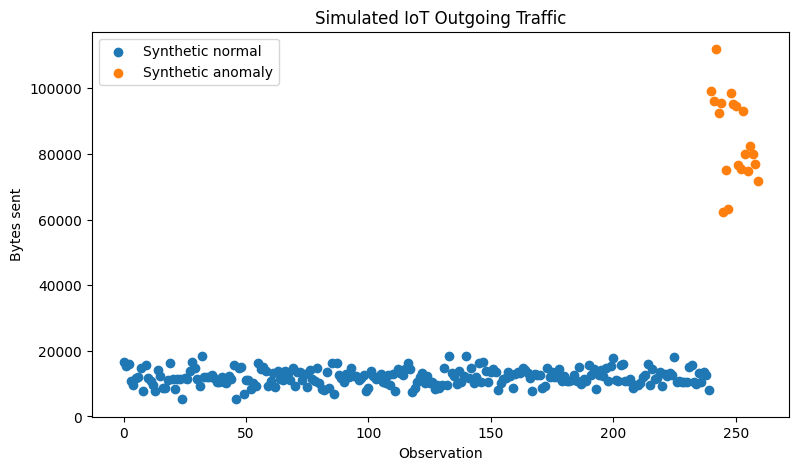

In [4]:
plt.figure(figsize=(9,5))
plt.scatter(df.index[df.known_anomaly==0],df.loc[df.known_anomaly==0,"bytes_sent"],label="Synthetic normal")
plt.scatter(df.index[df.known_anomaly==1],df.loc[df.known_anomaly==1,"bytes_sent"],label="Synthetic anomaly")
plt.xlabel("Observation")
plt.ylabel("Bytes sent")
plt.title("Simulated IoT Outgoing Traffic")
plt.legend()
plt.show()


## 3. Prepare Features

The model uses behavioural measurements rather than device identifiers. Features include hour, packets sent, bytes sent, bytes received, failed connections, unique destinations, and connection duration.


In [5]:
features=["hour","packets_sent","bytes_sent","bytes_received","failed_connections","unique_destinations","connection_duration_sec"]
X=df[features]
X.head()


,hour,packets_sent,bytes_sent,bytes_received,failed_connections,unique_destinations,connection_duration_sec
0,16,138,16705.061241,23416.268205,1,2,40.115564
1,13,118,15363.550115,24285.571856,0,3,53.235821
2,18,113,15982.966567,15855.239583,0,3,46.270733
3,15,133,10721.960809,16643.044540,0,6,52.012956
4,13,108,9525.987949,19000.528868,1,2,68.717287


## 4. Isolation Forest

Isolation Forest is an unsupervised anomaly-detection algorithm. It is fitted without using `known_anomaly`. That label is kept separate and is used only afterward for evaluation of this simulated experiment.


In [6]:
model=IsolationForest(n_estimators=200,contamination=0.08,random_state=42)
model.fit(X)

df["model_prediction"]=model.predict(X)
df["anomaly_score"]=model.decision_function(X)
df["ml_anomaly"]=(df["model_prediction"]==-1).astype(int)

df[["device_id","device_type","anomaly_score","ml_anomaly","known_anomaly"]].sort_values("anomaly_score").head(15)


,device_id,device_type,anomaly_score,ml_anomaly,known_anomaly
242,device_242,thermostat,-0.144880,1,1
248,device_248,smart_lock,-0.142146,1,1
240,device_240,sensor,-0.141425,1,1
251,device_251,thermostat,-0.140047,1,1
247,device_247,smart_lock,-0.138853,1,1
257,device_257,thermostat,-0.133197,1,1
253,device_253,thermostat,-0.121916,1,1
245,device_245,camera,-0.117788,1,1
252,device_252,sensor,-0.108065,1,1
244,device_244,smart_lock,-0.104620,1,1


## 5. Rule-Based Security Indicators

For comparison, a simple rule-based detector flags observations with very unusual hours, many failed connections, many destinations, or unusually large outgoing traffic. These thresholds are illustrative and would need validation in a real environment.


In [7]:
df["rule_alert"]=(
    (df.hour<6) |
    (df.failed_connections>=6) |
    (df.unique_destinations>=10) |
    (df.bytes_sent>=60000)
).astype(int)

df[["device_id","hour","failed_connections","unique_destinations","bytes_sent","rule_alert"]].head(10)


,device_id,hour,failed_connections,unique_destinations,bytes_sent,rule_alert
0,device_000,16,1,2,16705.061241,0
1,device_001,13,0,3,15363.550115,0
2,device_002,18,0,3,15982.966567,0
3,device_003,15,0,6,10721.960809,0
4,device_004,13,1,2,9525.987949,0
5,device_005,20,2,1,11685.532700,0
6,device_006,7,1,5,12139.312281,0
7,device_007,7,1,2,14735.478796,0
8,device_008,15,4,6,7768.838426,0
9,device_009,17,2,3,15823.875799,0


## 6. Compare Machine-Learning and Rule-Based Alerts

The comparison shows how automated anomaly detection and interpretable security rules can provide different signals. The purpose is not to declare one method universally better.


In [9]:
pd.crosstab(df["ml_anomaly"],df["rule_alert"],rownames=["ML anomaly"],colnames=["Rule alert"])


Rule alert,0,1
ML anomaly,,
0,239,0
1,1,20


## 7. Evaluation Using Synthetic Ground Truth

The `known_anomaly` label is not provided to the Isolation Forest during training. It is used only after prediction to measure performance on this particular simulated dataset.


In [10]:
print("Confusion Matrix:")
print(confusion_matrix(df["known_anomaly"],df["ml_anomaly"]))

print("\nClassification Report:")
print(classification_report(df["known_anomaly"],df["ml_anomaly"],target_names=["Normal","Anomaly"],zero_division=0))

print("Accuracy:",round(accuracy_score(df["known_anomaly"],df["ml_anomaly"]),3))


Confusion Matrix:
[[239   1]
 [  0  20]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       240
     Anomaly       0.95      1.00      0.98        20

    accuracy                           1.00       260
   macro avg       0.98      1.00      0.99       260
weighted avg       1.00      1.00      1.00       260

Accuracy: 0.996


## 8. Review Highest-Risk Observations

The observations with the lowest Isolation Forest scores are the observations the model considers most unusual. They are candidates for investigation, not confirmed security incidents.


In [12]:
top_alerts=df.sort_values("anomaly_score").head(10)
top_alerts[["device_id","device_type","hour","packets_sent","bytes_sent","bytes_received","failed_connections","unique_destinations","connection_duration_sec","anomaly_score","ml_anomaly","rule_alert","known_anomaly"]]


,device_id,device_type,hour,packets_sent,bytes_sent,bytes_received,failed_connections,unique_destinations,connection_duration_sec,anomaly_score,ml_anomaly,rule_alert,known_anomaly
242,device_242,thermostat,0,626,111926.072003,119219.915988,5,21,156.253011,-0.144880,1,1,1
248,device_248,smart_lock,5,578,98589.121619,104853.789726,14,21,136.013353,-0.142146,1,1,1
240,device_240,sensor,2,565,99293.497083,128973.795367,17,11,138.220115,-0.141425,1,1,1
251,device_251,thermostat,0,580,76778.495873,80831.169157,13,13,134.503700,-0.140047,1,1,1
247,device_247,smart_lock,2,632,63259.428848,154396.924222,11,8,163.058263,-0.138853,1,1,1
257,device_257,thermostat,0,597,80088.869459,119849.692715,17,14,215.280068,-0.133197,1,1,1
253,device_253,thermostat,5,626,93141.703984,121132.569036,6,11,232.519998,-0.121916,1,1,1
245,device_245,camera,5,604,62422.397523,127331.315144,9,18,91.191399,-0.117788,1,1,1
252,device_252,sensor,2,638,75405.753310,112823.071662,12,20,209.787422,-0.108065,1,1,1
244,device_244,smart_lock,3,644,95614.172707,130727.557052,7,17,223.119456,-0.104620,1,1,1


## 9. Discussion, Limitations and Future Work

This experiment demonstrates a basic workflow for behavioural security monitoring: collect activity measurements, explore the data, select behavioural features, apply unsupervised detection, compare with interpretable rules, and review alerts.

### Limitations
- The dataset is synthetic.
- The simulated anomalies may be easier to detect than real attacks.
- Device-specific normal behaviour is simplified.
- No real packet capture or production telemetry is used.
- The contamination setting is selected for this demonstration.

### Future Work
- Test the approach on a public IoT-security dataset.
- Compare Isolation Forest with other anomaly-detection methods.
- Develop device-specific behavioural baselines.
- Study false positives and alert fatigue.
- Explore lightweight models for resource-constrained IoT devices.
- Investigate privacy-preserving IoT telemetry analysis.

### Conclusion
This project provides a small experimental example of using machine learning for IoT security monitoring. Anomaly detection should be treated as decision support: an unusual observation can be flagged for investigation, but additional context is required before determining whether it represents a genuine security incident.
